In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/kaggle/input/datasets/hoorawan/titaniccc/titanic.csv"
)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

In [3]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

    
df['Age'].fillna(df['Age'].median(), inplace = True)

/tmp/ipykernel_55/133030122.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace = True)


In [4]:
df['Sex'] = df['Sex'].map({'male': 0, 'female' : 1})

In [5]:
X = df.drop('Survived', axis = 1)
y = df['Survived']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)


In [7]:
# Baseline Model - benchmark, standard

baseline_model = DummyClassifier(strategy = "most_frequent")
baseline_model.fit(X_train,y_train)




DummyClassifier(strategy='most_frequent')

In [8]:
# Supervised learning - Logistic Regression

from sklearn.linear_model import LogisticRegression


In [10]:
# model initialization

model = LogisticRegression(max_iter = 1000)


In [11]:
# model training

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [12]:
print("Weights", model.coef_)
print("Bias", model.intercept_)

Weights [[-9.96364826e-01  2.46563064e+00 -2.51645337e-02  1.18224793e-03]]
Bias [1.50122817]


In [22]:
# Predictions

y_pred = model.predict(X_test)



y_prob = model.predict_proba(X_test)

In [23]:
print("Predictions: ", y_pred[:5])
print("Probabilities: ", y_prob[:5])

Predictions:  [0 0 0 1 1]
Probabilities:  [[0.89793144 0.10206856]
 [0.77888637 0.22111363]
 [0.8788716  0.1211284 ]
 [0.13445193 0.86554807]
 [0.34552886 0.65447114]]


In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [27]:
# accuracy = correct predictions/ total predictions

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy", accuracy)

Accuracy 0.8044692737430168


In [28]:
cm = confusion_matrix(y_test,y_pred)

print("Confusion matrix",cm)

Confusion matrix [[90 15]
 [20 54]]


In [29]:
report = classification_report(y_test,y_pred)
print("Report", report)

Report               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [30]:
predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, predictions)
print("baseline accuracy", baseline_accuracy)

baseline accuracy 0.5865921787709497


In [31]:
y_train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Train accuracy: " , train_accuracy)



Train accuracy:  0.7907303370786517


In [ ]:
Feature Engineering & Model Improvement


1. Feature Creation - 
2. Feature Transformation - Log Transform, sqrt transform, power transform
3. Feature Encoding
4. Feature Selection -  heatmap correrlation 


In [ ]:
Feature Scaling 

1. Normalization  ( 0 - 1 )
2. Standardization Mean = 0 , Standard deviation = 1, ( -3 , +3) 

In [35]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

In [39]:
data = pd.DataFrame({
    "Age" : [10,20,30,40,50],
    "Fare" : [100, 200, 300, 400, 500]
})

# Normalization
minmax = MinMaxScaler()
data_norm = minmax.fit_transform(data)

Norm = X - min / max -min

# Standardization
std = StandardScaler()
data_std = std.fit_transform(data)



In [40]:
print("Orginal : ", data)
print("Normalized: ", data_norm)
print("Standardized: ", data_std)

Orginal :     Age  Fare
0   10   100
1   20   200
2   30   300
3   40   400
4   50   500
Normalized:  [[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [0.75 0.75]
 [1.   1.  ]]
Standardized:  [[-1.41421356 -1.41421356]
 [-0.70710678 -0.70710678]
 [ 0.          0.        ]
 [ 0.70710678  0.70710678]
 [ 1.41421356  1.41421356]]


In [42]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(pd.DataFrame(X_train).head())
print(pd.DataFrame(X_train_scaled).head())

     Pclass  Sex   Age     Fare
331       1    0  45.5  28.5000
733       2    0  23.0  13.0000
382       3    0  32.0   7.9250
704       3    0  26.0   7.8542
813       3    1   6.0  31.2750
          0         1         2         3
0 -1.614136 -0.724310  1.253641 -0.078684
1 -0.400551 -0.724310 -0.477284 -0.377145
2  0.813034 -0.724310  0.215086 -0.474867
3  0.813034 -0.724310 -0.246494 -0.476230
4  0.813034  1.380624 -1.785093 -0.025249


In [43]:
model_scaled = LogisticRegression(max_iter = 1000)
model_scaled.fit(X_train_scaled, y_train)


y_pred_scaled = model_scaled.predict(X_test_scaled)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print(accuracy_scaled)

0.7932960893854749


In [ ]:
Feature Transformation:   

Log Transformation- x' = log(X + 1) (right_skewed)
Square root Transformation - moderate skew

<function matplotlib.pyplot.show(close=None, block=None)>

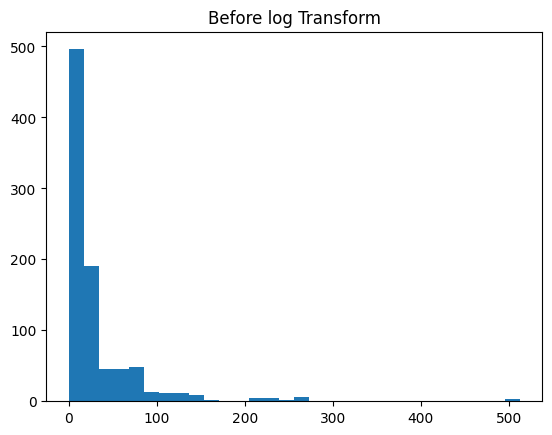

In [47]:
import numpy as np

df["Fare_log"] = np.log1p(df["Fare"])
df["Fare_sqrt"] = np.sqrt(df["Fare"])


import matplotlib.pyplot as plt


plt.hist(df["Fare"], bins = 30)
plt.title("Before log Transform")
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

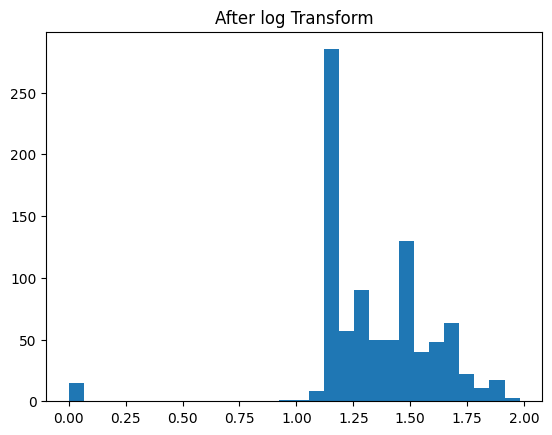

In [48]:
plt.hist(np.log1p(df["Fare_log"]), bins = 30)
plt.title("After log Transform")
plt.show
